In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

df = pd.read_csv(DATA_PROCESSED / "elliptic_clean.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (46564, 168)


,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [5]:
X = df.drop(columns=["label", "txId"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (46564, 166)
y shape: (46564,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (37251, 166)
Test: (9313, 166)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

rf_clean = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clean.fit(X_train, y_train)

clean_pred = rf_clean.predict(X_test)
clean_prob = rf_clean.predict_proba(X_test)[:,1]

clean_precision = precision_score(y_test, clean_pred)
clean_recall = recall_score(y_test, clean_pred)
clean_f1 = f1_score(y_test, clean_pred)
clean_pr_auc = average_precision_score(y_test, clean_prob)

print("Baseline Results")
print("Precision:", clean_precision)
print("Recall:", clean_recall)
print("F1:", clean_f1)
print("PR-AUC:", clean_pr_auc)

Baseline Results
Precision: 0.9974937343358395
Recall: 0.8756875687568757
F1: 0.9326303456356181
PR-AUC: 0.9800008914718656


In [8]:
import numpy as np

def flip_illicit_labels(y_series, flip_ratio=0.2, random_state=42):
    y_flipped = y_series.copy()

    rng = np.random.default_rng(random_state)

    # find illicit transactions (label = 1)
    illicit_indices = y_flipped[y_flipped == 1].index

    n_flip = int(len(illicit_indices) * flip_ratio)

    flip_indices = rng.choice(illicit_indices, size=n_flip, replace=False)

    # flip them (1 → 0)
    y_flipped.loc[flip_indices] = 0

    return y_flipped

In [9]:
flip_ratio = 0.20  # 20% attack

y_train_poisoned = flip_illicit_labels(y_train, flip_ratio)

print("Original illicit:", (y_train == 1).sum())
print("After poisoning:", (y_train_poisoned == 1).sum())

Original illicit: 3636
After poisoning: 2909


In [10]:
rf_poisoned = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_poisoned.fit(X_train, y_train_poisoned)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
poisoned_pred = rf_poisoned.predict(X_test)
poisoned_prob = rf_poisoned.predict_proba(X_test)[:,1]

poisoned_precision = precision_score(y_test, poisoned_pred)
poisoned_recall = recall_score(y_test, poisoned_pred)
poisoned_f1 = f1_score(y_test, poisoned_pred)
poisoned_pr_auc = average_precision_score(y_test, poisoned_prob)

print("Poisoned Results")
print("Precision:", poisoned_precision)
print("Recall:", poisoned_recall)
print("F1:", poisoned_f1)
print("PR-AUC:", poisoned_pr_auc)

Poisoned Results
Precision: 1.0
Recall: 0.8140814081408141
F1: 0.897513644633111
PR-AUC: 0.9759405951104729


In [12]:
from sklearn.metrics import confusion_matrix

clean_cm = confusion_matrix(y_test, clean_pred)
poisoned_cm = confusion_matrix(y_test, poisoned_pred)

clean_tn, clean_fp, clean_fn, clean_tp = clean_cm.ravel()
poisoned_tn, poisoned_fp, poisoned_fn, poisoned_tp = poisoned_cm.ravel()

print("Baseline FN:", clean_fn)
print("Poisoned FN:", poisoned_fn)

# Compliance Risk Score (FN more important)
clean_risk = 5 * clean_fn + clean_fp
poisoned_risk = 5 * poisoned_fn + poisoned_fp

print("\nCompliance Risk Score")
print("Baseline:", clean_risk)
print("Poisoned:", poisoned_risk)

Baseline FN: 113
Poisoned FN: 169

Compliance Risk Score
Baseline: 567
Poisoned: 845


In [13]:
final_df = pd.DataFrame({
    "Scenario": ["Baseline", "Poisoned_20%"],
    "Precision": [clean_precision, poisoned_precision],
    "Recall": [clean_recall, poisoned_recall],
    "F1 Score": [clean_f1, poisoned_f1],
    "PR-AUC": [clean_pr_auc, poisoned_pr_auc],
    "False Negatives": [clean_fn, poisoned_fn],
    "Compliance Risk": [clean_risk, poisoned_risk]
})

final_df

,Scenario,Precision,Recall,F1 Score,PR-AUC,False Negatives,Compliance Risk
0,Baseline,0.997494,0.875688,0.932630,0.980001,113,567
1,Poisoned_20%,1.000000,0.814081,0.897514,0.975941,169,845


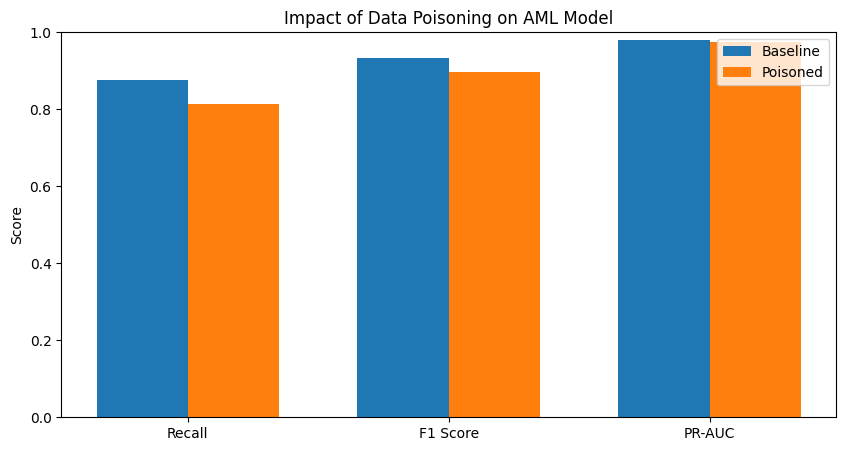

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Recall", "F1 Score", "PR-AUC"]

baseline_vals = [clean_recall, clean_f1, clean_pr_auc]
poisoned_vals = [poisoned_recall, poisoned_f1, poisoned_pr_auc]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, baseline_vals, width, label="Baseline")
plt.bar(x + width/2, poisoned_vals, width, label="Poisoned")

plt.xticks(x, metrics)
plt.ylim(0,1)
plt.title("Impact of Data Poisoning on AML Model")
plt.ylabel("Score")
plt.legend()

plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/processed/elliptic_clean.csv")

target_col = "label"

X = df.drop(columns=[target_col, "txId"])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (46564, 166)
y shape: (46564,)
label
0    42019
1     4545
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (37251, 166)
X_test shape: (9313, 166)
y_train shape: (37251,)
y_test shape: (9313,)


In [4]:
poison_rate = 0.20

y_train_poisoned = y_train.copy()

n_poison = int(len(y_train_poisoned) * poison_rate)
poison_indices = np.random.choice(y_train_poisoned.index, size=n_poison, replace=False)

y_train_poisoned.loc[poison_indices] = 1 - y_train_poisoned.loc[poison_indices]

print("Poison rate:", poison_rate)
print("Number of flipped labels:", n_poison)
print(y_train.value_counts(), "\n")
print(y_train_poisoned.value_counts())

Poison rate: 0.2
Number of flipped labels: 7450
label
0    33615
1     3636
Name: count, dtype: int64 

label
0    27631
1     9620
Name: count, dtype: int64


In [5]:
X_train_poisoned = X_train.copy()

In [6]:
rf_poisoned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_poisoned.fit(X_train_poisoned, y_train_poisoned)

rf_poisoned_pred = rf_poisoned.predict(X_test)
rf_poisoned_prob = rf_poisoned.predict_proba(X_test)[:, 1]

rf_poisoned_precision = precision_score(y_test, rf_poisoned_pred)
rf_poisoned_recall = recall_score(y_test, rf_poisoned_pred)
rf_poisoned_f1 = f1_score(y_test, rf_poisoned_pred)
rf_poisoned_pr_auc = average_precision_score(y_test, rf_poisoned_prob)

print("Poisoned Random Forest Results")
print("Precision:", rf_poisoned_precision)
print("Recall:", rf_poisoned_recall)
print("F1 Score:", rf_poisoned_f1)
print("PR-AUC:", rf_poisoned_pr_auc)
print(classification_report(y_test, rf_poisoned_pred))

Poisoned Random Forest Results
Precision: 0.8830472103004292
Recall: 0.9053905390539054
F1 Score: 0.8940793047256925
PR-AUC: 0.9473999411516362
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8404
           1       0.88      0.91      0.89       909

    accuracy                           0.98      9313
   macro avg       0.94      0.95      0.94      9313
weighted avg       0.98      0.98      0.98      9313



In [7]:
ada_poisoned = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_poisoned.fit(X_train_poisoned, y_train_poisoned)

ada_poisoned_pred = ada_poisoned.predict(X_test)
ada_poisoned_prob = ada_poisoned.predict_proba(X_test)[:, 1]

ada_poisoned_precision = precision_score(y_test, ada_poisoned_pred)
ada_poisoned_recall = recall_score(y_test, ada_poisoned_pred)
ada_poisoned_f1 = f1_score(y_test, ada_poisoned_pred)
ada_poisoned_pr_auc = average_precision_score(y_test, ada_poisoned_prob)

print("Poisoned AdaBoost Results")
print("Precision:", ada_poisoned_precision)
print("Recall:", ada_poisoned_recall)
print("F1 Score:", ada_poisoned_f1)
print("PR-AUC:", ada_poisoned_pr_auc)
print(classification_report(y_test, ada_poisoned_pred))

Poisoned AdaBoost Results
Precision: 0.9156050955414012
Recall: 0.6325632563256326
F1 Score: 0.7482108002602472
PR-AUC: 0.7882186827387613
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      8404
           1       0.92      0.63      0.75       909

    accuracy                           0.96      9313
   macro avg       0.94      0.81      0.86      9313
weighted avg       0.96      0.96      0.95      9313



In [8]:
scale_pos_weight_poisoned = (y_train_poisoned == 0).sum() / (y_train_poisoned == 1).sum()

xgb_poisoned = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_poisoned
)

xgb_poisoned.fit(X_train_poisoned, y_train_poisoned)

xgb_poisoned_pred = xgb_poisoned.predict(X_test)
xgb_poisoned_prob = xgb_poisoned.predict_proba(X_test)[:, 1]

xgb_poisoned_precision = precision_score(y_test, xgb_poisoned_pred)
xgb_poisoned_recall = recall_score(y_test, xgb_poisoned_pred)
xgb_poisoned_f1 = f1_score(y_test, xgb_poisoned_pred)
xgb_poisoned_pr_auc = average_precision_score(y_test, xgb_poisoned_prob)

print("Poisoned XGBoost Results")
print("Precision:", xgb_poisoned_precision)
print("Recall:", xgb_poisoned_recall)
print("F1 Score:", xgb_poisoned_f1)
print("PR-AUC:", xgb_poisoned_pr_auc)
print(classification_report(y_test, xgb_poisoned_pred))

Poisoned XGBoost Results
Precision: 0.4954233409610984
Recall: 0.9526952695269527
F1 Score: 0.6518630033872789
PR-AUC: 0.948429733647267
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      8404
           1       0.50      0.95      0.65       909

    accuracy                           0.90      9313
   macro avg       0.74      0.92      0.80      9313
weighted avg       0.95      0.90      0.91      9313



In [9]:
rf_cm = confusion_matrix(y_test, rf_poisoned_pred)
ada_cm = confusion_matrix(y_test, ada_poisoned_pred)
xgb_cm = confusion_matrix(y_test, xgb_poisoned_pred)

rf_fp, rf_fn = rf_cm[0, 1], rf_cm[1, 0]
ada_fp, ada_fn = ada_cm[0, 1], ada_cm[1, 0]
xgb_fp, xgb_fn = xgb_cm[0, 1], xgb_cm[1, 0]

poisoned_results = pd.DataFrame({
    "Scenario": ["After Attack", "After Attack", "After Attack"],
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Poison Rate": [int(poison_rate * 100)] * 3,
    "Precision": [rf_poisoned_precision, ada_poisoned_precision, xgb_poisoned_precision],
    "Recall": [rf_poisoned_recall, ada_poisoned_recall, xgb_poisoned_recall],
    "F1 Score": [rf_poisoned_f1, ada_poisoned_f1, xgb_poisoned_f1],
    "PR-AUC": [rf_poisoned_pr_auc, ada_poisoned_pr_auc, xgb_poisoned_pr_auc],
    "False Positives": [rf_fp, ada_fp, xgb_fp],
    "False Negatives": [rf_fn, ada_fn, xgb_fn]
})

poisoned_results

,Scenario,Model,Poison Rate,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives
0,After Attack,Random Forest,20,0.883047,0.905391,0.894079,0.947400,109,86
1,After Attack,AdaBoost,20,0.915605,0.632563,0.748211,0.788219,53,334
2,After Attack,XGBoost,20,0.495423,0.952695,0.651863,0.948430,882,43


In [10]:
baseline_results = pd.read_csv("../results/tables/baseline_results.csv")

comparison_clean_vs_poisoned = baseline_results.merge(
    poisoned_results,
    on="Model",
    suffixes=("_Clean", "_Poisoned")
)

comparison_clean_vs_poisoned

,Model,Precision_Clean,Recall_Clean,F1 Score_Clean,PR-AUC_Clean,False Negatives_Clean,Scenario,Poison Rate,Precision_Poisoned,Recall_Poisoned,F1 Score_Poisoned,PR-AUC_Poisoned,False Positives,False Negatives_Poisoned
0,Random Forest,0.997494,0.875688,0.93263,0.980001,113,After Attack,20,0.883047,0.905391,0.894079,0.9474,109,86


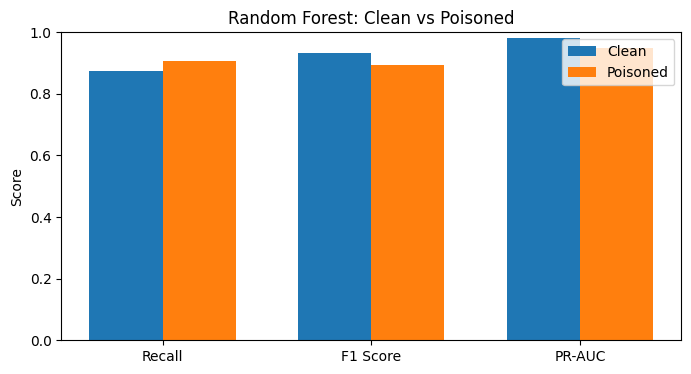

IndexError: single positional indexer is out-of-bounds

In [11]:
metrics = ["Recall", "F1 Score", "PR-AUC"]

for model in poisoned_results["Model"]:
    clean_row = baseline_results[baseline_results["Model"] == model].iloc[0]
    poisoned_row = poisoned_results[poisoned_results["Model"] == model].iloc[0]

    clean_vals = [clean_row["Recall"], clean_row["F1 Score"], clean_row["PR-AUC"]]
    poisoned_vals = [poisoned_row["Recall"], poisoned_row["F1 Score"], poisoned_row["PR-AUC"]]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, clean_vals, width, label="Clean")
    plt.bar(x + width/2, poisoned_vals, width, label="Poisoned")
    plt.xticks(x, metrics)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"{model}: Clean vs Poisoned")
    plt.legend()
    plt.show()

In [12]:
print("Baseline models:", baseline_results["Model"].tolist())
print("Poisoned models:", poisoned_results["Model"].tolist())

Baseline models: ['Random Forest']
Poisoned models: ['Random Forest', 'AdaBoost', 'XGBoost']


In [13]:
baseline_results["Model"] = baseline_results["Model"].astype(str).str.strip()
poisoned_results["Model"] = poisoned_results["Model"].astype(str).str.strip()

print("Baseline models:", baseline_results["Model"].tolist())
print("Poisoned models:", poisoned_results["Model"].tolist())

Baseline models: ['Random Forest']
Poisoned models: ['Random Forest', 'AdaBoost', 'XGBoost']


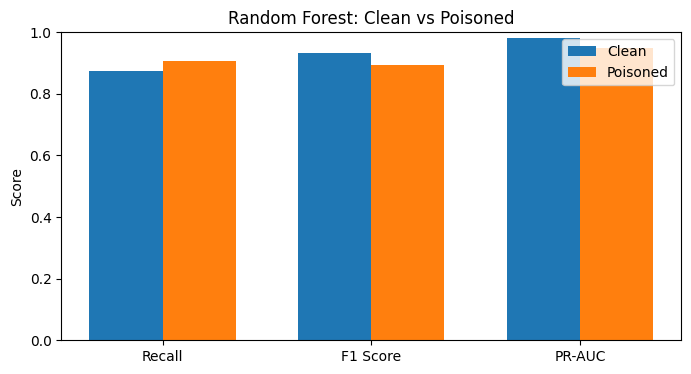

Skipping AdaBoost because it was not found in both tables.
Skipping XGBoost because it was not found in both tables.


In [14]:
metrics = ["Recall", "F1 Score", "PR-AUC"]

baseline_results["Model"] = baseline_results["Model"].astype(str).str.strip()
poisoned_results["Model"] = poisoned_results["Model"].astype(str).str.strip()

for model in poisoned_results["Model"].unique():
    clean_match = baseline_results[baseline_results["Model"] == model]
    poisoned_match = poisoned_results[poisoned_results["Model"] == model]

    if clean_match.empty or poisoned_match.empty:
        print(f"Skipping {model} because it was not found in both tables.")
        continue

    clean_row = clean_match.iloc[0]
    poisoned_row = poisoned_match.iloc[0]

    clean_vals = [clean_row["Recall"], clean_row["F1 Score"], clean_row["PR-AUC"]]
    poisoned_vals = [poisoned_row["Recall"], poisoned_row["F1 Score"], poisoned_row["PR-AUC"]]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, clean_vals, width, label="Clean")
    plt.bar(x + width/2, poisoned_vals, width, label="Poisoned")
    plt.xticks(x, metrics)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"{model}: Clean vs Poisoned")
    plt.legend()
    plt.show()

In [15]:
baseline_results
poisoned_results

,Scenario,Model,Poison Rate,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives
0,After Attack,Random Forest,20,0.883047,0.905391,0.894079,0.947400,109,86
1,After Attack,AdaBoost,20,0.915605,0.632563,0.748211,0.788219,53,334
2,After Attack,XGBoost,20,0.495423,0.952695,0.651863,0.948430,882,43


In [17]:
baseline_results = pd.read_csv("../results/tables/baseline_results.csv")
baseline_results["Model"] = baseline_results["Model"].astype(str).str.strip()
poisoned_results["Model"] = poisoned_results["Model"].astype(str).str.strip()

print(baseline_results)
print(poisoned_results)

           Model  Precision    Recall  F1 Score    PR-AUC  False Positives  \
0  Random Forest   0.957324  0.913091  0.934685  0.975411               37   
1       AdaBoost   0.904389  0.634763  0.745960  0.838682               61   
2        XGBoost   0.929108  0.951595  0.940217  0.984936               66   

   False Negatives  
0               79  
1              332  
2               44  
       Scenario          Model  Poison Rate  Precision    Recall  F1 Score  \
0  After Attack  Random Forest           20   0.883047  0.905391  0.894079   
1  After Attack       AdaBoost           20   0.915605  0.632563  0.748211   
2  After Attack        XGBoost           20   0.495423  0.952695  0.651863   

     PR-AUC  False Positives  False Negatives  
0  0.947400              109               86  
1  0.788219               53              334  
2  0.948430              882               43  


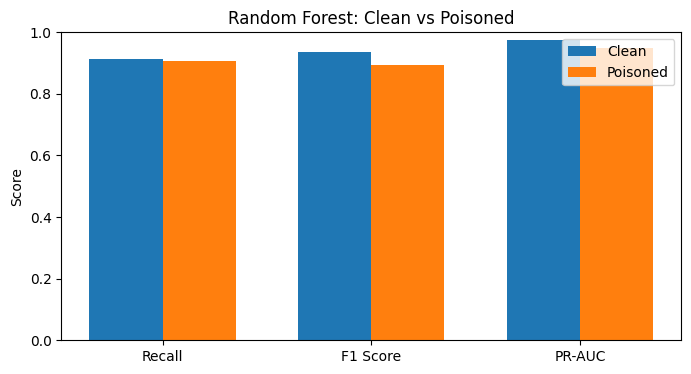

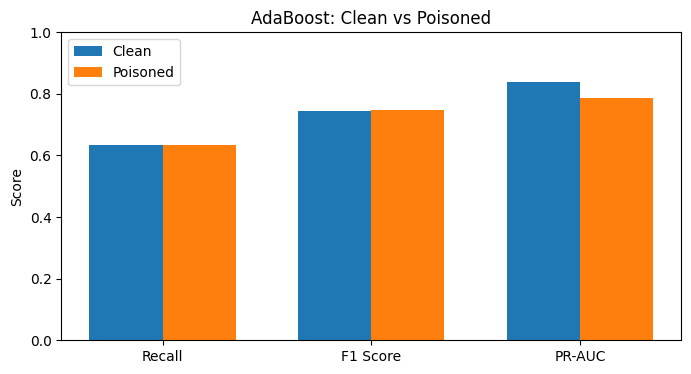

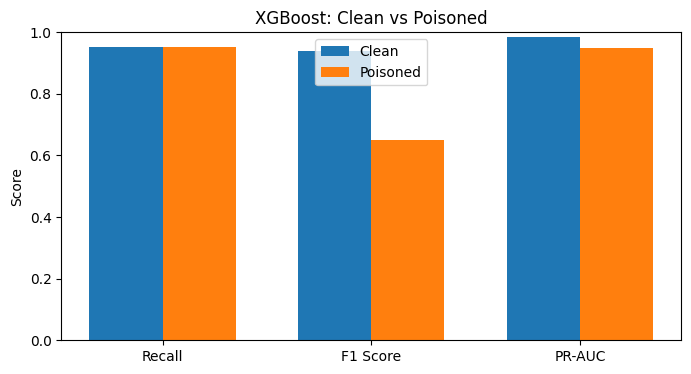

In [18]:
metrics = ["Recall", "F1 Score", "PR-AUC"]

for model in ["Random Forest", "AdaBoost", "XGBoost"]:
    clean_row = baseline_results[baseline_results["Model"] == model].iloc[0]
    poisoned_row = poisoned_results[poisoned_results["Model"] == model].iloc[0]

    clean_vals = [clean_row["Recall"], clean_row["F1 Score"], clean_row["PR-AUC"]]
    poisoned_vals = [poisoned_row["Recall"], poisoned_row["F1 Score"], poisoned_row["PR-AUC"]]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, clean_vals, width, label="Clean")
    plt.bar(x + width/2, poisoned_vals, width, label="Poisoned")
    plt.xticks(x, metrics)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"{model}: Clean vs Poisoned")
    plt.legend()
    plt.show()

In [19]:
poisoned_results.to_csv("../results/tables/poisoned_results.csv", index=False)